In [109]:
# --- 1. Manipulation de données et Calculs ---
import pandas as pd
import numpy as np

# --- 2. Visualisation graphique ---
import matplotlib.pyplot as plt
import seaborn as sns
# Permet d'afficher les graphiques directement sous les cellules
%matplotlib inline 
# Configuration du style des graphiques (optionnel, pour faire plus joli)
sns.set(style="whitegrid")

# --- 3. Prétraitement (Preprocessing) & Séparation ---
# Pour séparer Train / Test
from sklearn.model_selection import train_test_split
# Pour la validation croisée et la recherche des meilleurs paramètres
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
# Pour mettre les données à l'échelle (Scaling)
from sklearn.preprocessing import StandardScaler, MinMaxScaler
# Pour encoder les variables textuelles (si besoin)
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

# --- 4. Algorithmes de Machine Learning (Modèles) ---
# Vos modèles actuels
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
# Je vous conseille d'importer aussi ceux-ci pour comparer (optionnel)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# --- 5. Métriques d'évaluation ---
from sklearn.metrics import (
    accuracy_score,
    recall_score,       # Très important pour votre cas (ne pas rater les départs)
    precision_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# --- 6. Gestion du système et des alertes ---
import warnings
# Pour éviter d'être pollué par les messages d'avertissement rouges lors du GridSearch
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.pipeline import Pipeline


In [110]:
# chargement des données 
data_ready = pd.read_pickle("data_ready_for_model.pkl")

X = data_ready['X']
y = data_ready['y']
X= X.drop(columns=["Unnamed: 0"])


print("=" * 80)
print("DATASET CHARGÉ AVEC SUCCÈS")
print("=" * 80)
print(f" Features (X) : {X.shape[0]} lignes × {X.shape[1]} colonnes")
print(f" Target (y)   : {y.shape[0]} valeurs")
print(f"\n Répartition de la cible :")
print(y.value_counts())
print(f"\n   → Attrition : {(y.sum() / len(y) * 100):.2f}%")
print("=" * 80)



DATASET CHARGÉ AVEC SUCCÈS
 Features (X) : 4410 lignes × 22 colonnes
 Target (y)   : 4410 valeurs

 Répartition de la cible :
Attrition
0    3699
1     711
Name: count, dtype: int64

   → Attrition : 16.12%


In [111]:
X

,Friday_Evening_Presence_Rate,Overtime_Days_8.5h,Avg_Daily_Hours,TotalWorkingYears,YearsWithCurrManager,Overtime_Days_10h,YearsAtCompany,Early_Leave_Rate,JobSatisfaction,EnvironmentSatisfaction,BusinessTravel,Age_Group,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,Department_Research & Development,Department_Sales
0,-0.806542,-0.585157,-0.244095,-1.321929,-1.155804,-0.363226,-0.980903,-0.606504,1.156171,0.252172,1,3.0,False,False,False,False,False,False,False,False,False,True
1,-0.222930,-0.564287,0.013563,-0.678800,-0.034516,-0.363226,-0.327856,-0.663990,-0.663823,0.252172,2,1.0,False,False,False,False,False,True,False,False,True,False
2,-0.806542,-0.585157,-0.513015,-0.807426,-0.314838,-0.363226,-0.327856,-0.319072,-0.663823,-0.665384,2,1.0,False,False,False,False,False,False,True,False,True,False
3,-0.753486,-0.585157,-0.378381,0.221581,0.245806,-0.363226,0.161929,-0.534646,1.156171,1.169728,0,2.0,True,False,False,False,False,False,False,False,True,False
4,0.360682,-0.397333,0.227861,-0.292923,-0.034516,-0.363226,-0.164594,-0.678362,-1.573821,1.169728,1,1.0,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4405,1.209572,0.698305,0.612949,-0.164297,-0.595160,-0.363226,-0.654380,-0.678362,-1.573821,1.169728,1,2.0,False,False,False,False,False,True,False,False,True,False
4406,-0.806542,-0.585157,-1.199684,-0.164297,-0.595160,-0.363226,-0.654380,2.267813,1.156171,1.169728,1,1.0,False,True,False,False,False,False,False,False,True,False
4407,-0.488208,-0.585157,0.004358,-0.807426,-0.595160,-0.363226,-0.491118,-0.678362,0.246174,-1.582940,1,1.0,False,False,False,False,False,False,True,False,True,False
4408,1.634017,1.929594,1.336949,-0.164297,1.086772,-0.119935,0.325191,-0.678362,-1.573821,1.169728,1,2.0,False,True,False,False,False,False,False,False,False,True


# STRATÉGIE DE VALIDATION CROISÉE

## 5.1 Configuration de la Cross-Validation Stratifiée
 **Pourquoi Stratified K-Fold ?**
 - Conserve la proportion Attrition (~16%) dans chaque fold
 - Évite les folds déséquilibrés qui fausseraient l'évaluation
 
 **Paramètres** :
 - `n_splits=5` : Bon compromis précision/temps de calcul
 - `shuffle=True` : Mélange aléatoire des données
 - `random_state=42` : Reproductibilité des résultats

In [112]:


def stratified_cv_splits(X, y, n_splits=5, random_state=42, shuffle=True):
    """
    Retourne les indices train/val pour une CV stratifiée.
    """
    skf = StratifiedKFold(n_splits=n_splits, shuffle=shuffle, random_state=random_state)
    splits = list(skf.split(X, y))
    
    print(f" Stratified K-Fold configuré : {n_splits} folds")
    print(f"   → Chaque fold train : ~{int(X.shape[0]*(n_splits-1)/n_splits)} lignes")
    print(f"   → Chaque fold val   : ~{int(X.shape[0]/n_splits)} lignes")
    print(f"   → Proportion Attrition préservée dans chaque fold\n")
    
    return splits

# Création des splits (réutilisables pour tous les modèles)
cv_splits = stratified_cv_splits(X, y, n_splits=10)

 Stratified K-Fold configuré : 10 folds
   → Chaque fold train : ~3969 lignes
   → Chaque fold val   : ~441 lignes
   → Proportion Attrition préservée dans chaque fold



Objectif : Générer des indices de découpage pour la validation croisée. Pourquoi Stratified ? Notre dataset est déséquilibré (Attrition ~16%). La stratification garantit que chaque "fold" (paquet) contient exactement la même proportion de départs que le dataset original. Cela évite d'avoir un fold "vide" où le modèle n'apprendrait rien.

 **Métriques utilisées** :
 - **AUC-ROC** : Capacité à discriminer les classes
- **F1-Score** : Équilibre Precision/Recall
 - **Precision** : % de vrais positifs parmi les prédictions positives
 - **Recall** : % de vrais positifs détectés

In [113]:
def evaluate_model_on_cv(model, splits, X, y, metrics=['auc', 'f1', 'precision', 'recall']):
    """
    Évalue un modèle sur tous les folds et retourne les scores moyens.
    """
    scores = {m: [] for m in metrics}
    
    for fold, (train_idx, val_idx) in enumerate(splits, 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        
        # Entraînement
        model.fit(X_train, y_train)
        
        # Prédictions
        pred_proba = model.predict_proba(X_val)[:, 1]
        pred_class = (pred_proba >= 0.5).astype(int)
        
        # Calcul métriques
        if 'auc' in metrics:
            scores['auc'].append(roc_auc_score(y_val, pred_proba))
        if 'f1' in metrics:
            scores['f1'].append(f1_score(y_val, pred_class))
        if 'precision' in metrics:
            scores['precision'].append(precision_score(y_val, pred_class))
        if 'recall' in metrics:
            scores['recall'].append(recall_score(y_val, pred_class))
        
        print(f"Fold {fold} – AUC: {scores['auc'][-1]:.4f} | F1: {scores['f1'][-1]:.4f}")
    
    # Moyennes finales
    print("\n" + "=" * 50)
    print("RÉSULTATS MOYENS SUR 5 FOLDS STRATIFIÉS :")
    for m in metrics:
        mean = np.mean(scores[m])
        std = np.std(scores[m])
        print(f"{m.upper():9} : {mean:.4f} ± {std:.4f}")
    print("=" * 50)
    
    return scores

Objectif : Entraîner et tester un modèle sur chaque fold successivement. Fonctionnement :

Elle reçoit le modèle (ou le Pipeline).

Elle isole les données Train et Val grâce aux indices.

Important : Le fit se fait à l'intérieur de la boucle. Si le modèle est un Pipeline avec StandardScaler, le scaling est calculé ici sur le Train uniquement (pas de fuite de données).

Elle calcule la moyenne des scores pour donner une note fiable.

#  MODÉLISATION ET ÉVALUATION

# Le Dictionnaire de Modèles

In [114]:
dict_modeles = {
    # --- Modèles de base (Baseline) ---
    # Pas besoin de scaling pour le Dummy
    "Dummy Classifier": DummyClassifier(strategy='stratified', random_state=42),

    # --- Modèles nécessitant du Scaling (PIPELINES) ---
    # Le pipeline va d'abord Scaler, puis appliquer la régression
    "Logistic Regression": make_pipeline(
        StandardScaler(), 
        LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced", solver="lbfgs")
    ),
    
    # KNN déteste les données non scalées -> Pipeline obligatoire
    "K-Nearest Neighbors (K=5)": make_pipeline(
        StandardScaler(),
        KNeighborsClassifier(n_neighbors=5)
    ),

    # SVM est très sensible à l'échelle -> Pipeline obligatoire
    "SVM (Kernel RBF)": make_pipeline(
        StandardScaler(),
        SVC(kernel='rbf', probability=True, class_weight="balanced", random_state=42)
    ),

    # --- Arbres et Ensembles (PAS BESOIN DE SCALING) ---
    # Ils gèrent les données brutes sans problème
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    
    "Random Forest": RandomForestClassifier(
        n_estimators=100, 
        class_weight="balanced",
        random_state=42, 
        n_jobs=-1
    ),
    
    "XGBoost": XGBClassifier(
        n_estimators=100, 
        learning_rate=0.1, 
        use_label_encoder=False, 
        eval_metric='logloss',
        random_state=42,
        n_jobs=-1
    )
}

Structure : Ce dictionnaire associe un nom (clé) à un objet modèle (valeur). Pipelines : Remarquez l'utilisation de make_pipeline(StandardScaler(), Modele()).

Les modèles basés sur la distance (KNN, SVM, LogReg) doivent être dans un pipeline avec un scaler.

Les modèles basés sur les arbres (RandomForest, XGBoost) peuvent travailler sur les données brutes.

## 6.1 Baseline : Modèle de référence

 Avant de tester des modèles complexes, établissons une **baseline** simple.
 
 **Exemple** : 

In [115]:
# --- 1. BASELINE NAÏVE (Le Hasard) ---
print("---  ÉVALUATION BASELINE NAÏVE (DUMMY) ---")
model_dummy = dict_modeles["Dummy Classifier"]
scores_dummy = evaluate_model_on_cv(model_dummy, cv_splits, X, y)

# --- 2. BASELINE LINEAIRE (La Référence) ---
print("\n---  ÉVALUATION BASELINE INTELLIGENTE (LOGISTIC REGRESSION) ---")
model_log = dict_modeles["Logistic Regression"]
# Note : Assurez-vous que X est scalé pour la régression logistique, 
# sinon le résultat sera mauvais.
scores_log = evaluate_model_on_cv(model_log, cv_splits, X, y)

---  ÉVALUATION BASELINE NAÏVE (DUMMY) ---
Fold 1 – AUC: 0.4991 | F1: 0.1571
Fold 2 – AUC: 0.4655 | F1: 0.1000
Fold 3 – AUC: 0.5075 | F1: 0.1714
Fold 4 – AUC: 0.4823 | F1: 0.1286
Fold 5 – AUC: 0.4823 | F1: 0.1286
Fold 6 – AUC: 0.5494 | F1: 0.2429
Fold 7 – AUC: 0.5075 | F1: 0.1714
Fold 8 – AUC: 0.4991 | F1: 0.1571
Fold 9 – AUC: 0.5243 | F1: 0.2000
Fold 10 – AUC: 0.4812 | F1: 0.1277

RÉSULTATS MOYENS SUR 5 FOLDS STRATIFIÉS :
AUC       : 0.4998 ± 0.0231
F1        : 0.1585 ± 0.0392
PRECISION : 0.1609 ± 0.0397
RECALL    : 0.1562 ± 0.0387

---  ÉVALUATION BASELINE INTELLIGENTE (LOGISTIC REGRESSION) ---
Fold 1 – AUC: 0.8281 | F1: 0.4825
Fold 2 – AUC: 0.7636 | F1: 0.4128
Fold 3 – AUC: 0.7495 | F1: 0.4298
Fold 4 – AUC: 0.7474 | F1: 0.4190
Fold 5 – AUC: 0.7593 | F1: 0.4537
Fold 6 – AUC: 0.8117 | F1: 0.4622
Fold 7 – AUC: 0.7727 | F1: 0.4557
Fold 8 – AUC: 0.7981 | F1: 0.4473
Fold 9 – AUC: 0.7451 | F1: 0.3797
Fold 10 – AUC: 0.7544 | F1: 0.4082

RÉSULTATS MOYENS SUR 5 FOLDS STRATIFIÉS :
AUC       : 

In [75]:
print(X.dtypes[X.dtypes == "object"])
print("Nb colonnes object =", (X.dtypes == "object").sum())


Series([], dtype: object)
Nb colonnes object = 0


#  COMPARAISON DES MODÈLES 


In [77]:

# Liste des modèles à tester (excluant les baselines déjà faites)
challengers = [
"K-Nearest Neighbors (K=5)", 
    "SVM (Kernel RBF)",
    "Decision Tree", 
    "Random Forest", 
    "XGBoost"
]

print("\n" + "#"*30)
print(" DÉBUT DU BENCHMARK COMPARATIF ")
print("#"*30)

for nom in challengers:
    if nom in dict_modeles:
        print(f"\n---  ENTRAÎNEMENT : {nom} ---")
        modele = dict_modeles[nom]
        # On passe X et y, le pipeline gère le scaling si nécessaire
        evaluate_model_on_cv(modele, cv_splits, X, y)
    else:
        print(f" Attention : Le modèle '{nom}' n'est pas dans le dictionnaire.")


##############################
 DÉBUT DU BENCHMARK COMPARATIF 
##############################

---  ENTRAÎNEMENT : K-Nearest Neighbors (K=5) ---
Fold 1 – AUC: 0.9291 | F1: 0.5098
Fold 2 – AUC: 0.9176 | F1: 0.4400
Fold 3 – AUC: 0.9159 | F1: 0.5138
Fold 4 – AUC: 0.9176 | F1: 0.3878
Fold 5 – AUC: 0.9119 | F1: 0.4074
Fold 6 – AUC: 0.9283 | F1: 0.5500
Fold 7 – AUC: 0.8875 | F1: 0.4068
Fold 8 – AUC: 0.9289 | F1: 0.5047
Fold 9 – AUC: 0.9012 | F1: 0.4510
Fold 10 – AUC: 0.9119 | F1: 0.5000

RÉSULTATS MOYENS SUR 5 FOLDS STRATIFIÉS :
AUC       : 0.9150 ± 0.0124
F1        : 0.4671 ± 0.0528
PRECISION : 0.6968 ± 0.0881
RECALL    : 0.3558 ± 0.0544

---  ENTRAÎNEMENT : SVM (Kernel RBF) ---
Fold 1 – AUC: 0.9139 | F1: 0.7111
Fold 2 – AUC: 0.8710 | F1: 0.6393
Fold 3 – AUC: 0.8978 | F1: 0.6452
Fold 4 – AUC: 0.8760 | F1: 0.5920
Fold 5 – AUC: 0.9056 | F1: 0.6387
Fold 6 – AUC: 0.9291 | F1: 0.7273
Fold 7 – AUC: 0.8497 | F1: 0.5693
Fold 8 – AUC: 0.9143 | F1: 0.6406
Fold 9 – AUC: 0.8817 | F1: 0.6387
Fold 10 – 

# METHODE 1 : LE TABLEAU DES ECARTS (GAP ANALYSIS)

CALCUL DES ECARTS TRAIN vs TEST (Detection Overfitting)...

Résultats de l'analyse d'Overfitting :
                           Train AUC  Test AUC (Val)  Écart (Gap)  \
Modèle                                                              
Decision Tree               1.000000        0.924324     0.075676   
K-Nearest Neighbors (K=5)   0.983272        0.914984     0.068288   
SVM (Kernel RBF)            0.950459        0.893197     0.057263   
XGBoost                     0.999475        0.978720     0.020755   
Logistic Regression         0.783807        0.772716     0.011091   
Random Forest               1.000000        0.997942     0.002058   
Dummy Classifier            0.492626        0.499816    -0.007190   

                                           Diagnostic  
Modèle                                                 
Decision Tree                      Overfitting modéré  
K-Nearest Neighbors (K=5)          Overfitting modéré  
SVM (Kernel RBF)                   Overfitting modéré  

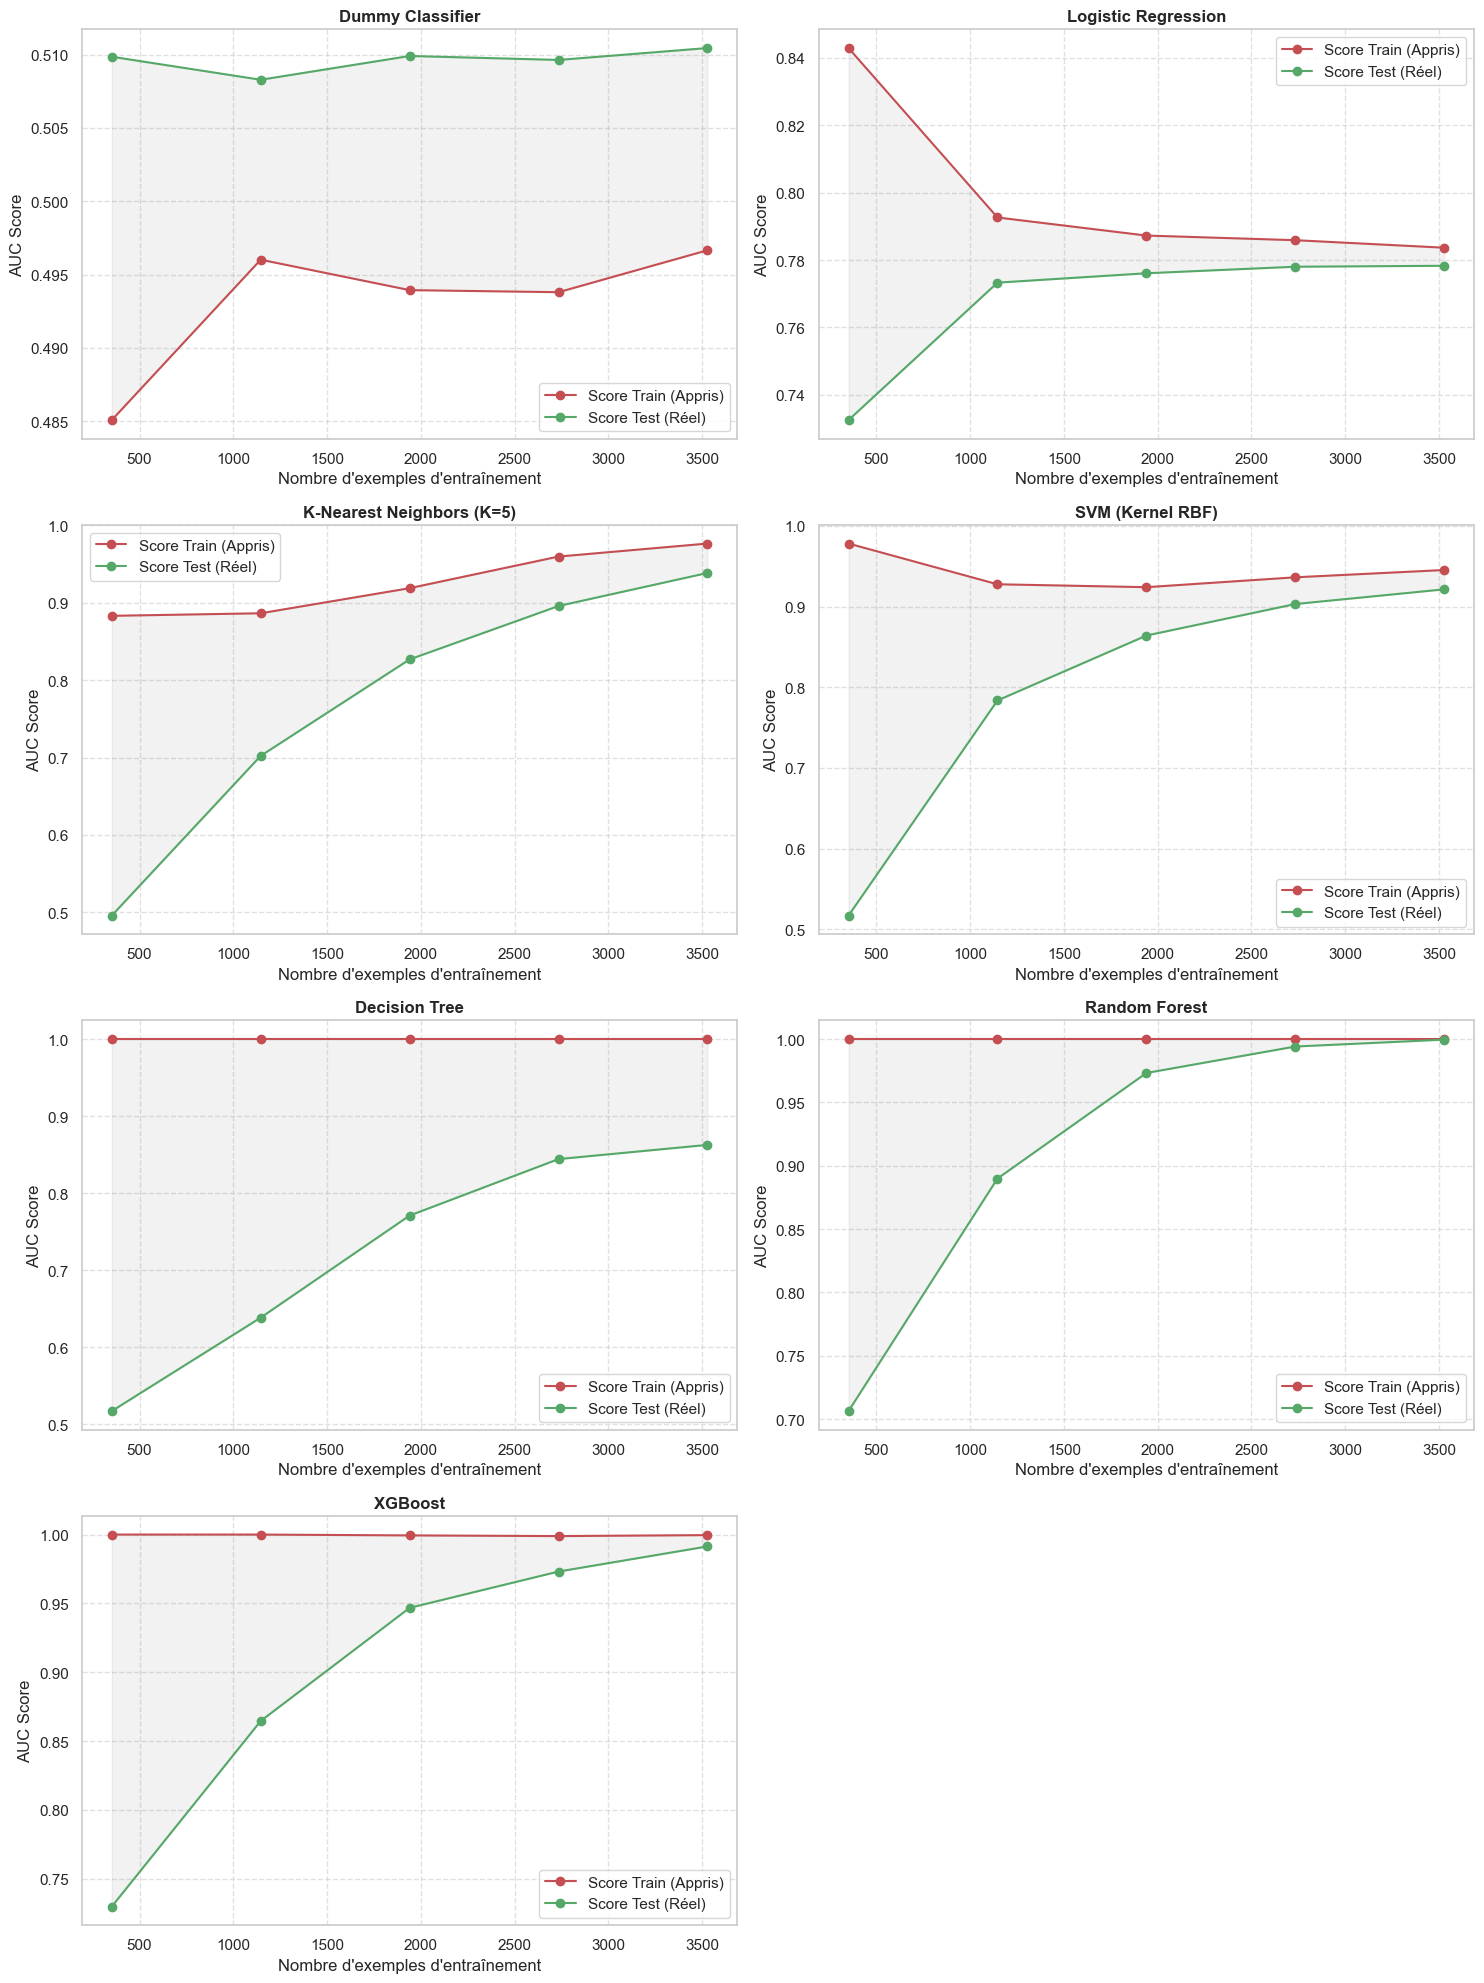

In [78]:


# ==============================================================================
# METHODE 1 : LE TABLEAU DES ECARTS (GAP ANALYSIS)
# ==============================================================================

print("CALCUL DES ECARTS TRAIN vs TEST (Detection Overfitting)...\n")

overfitting_results = []

for nom_modele, modele in dict_modeles.items():
    # cross_validate permet de récupérer le score d'entraînement avec return_train_score=True
    cv_results = cross_validate(modele, X, y, cv=cv_splits, 
                                scoring='roc_auc', 
                                return_train_score=True, 
                                n_jobs=-1)
    
    train_auc = cv_results['train_score'].mean()
    test_auc = cv_results['test_score'].mean()
    gap = train_auc - test_auc
    
    # Diagnostic automatique
    if gap > 0.10:
        statut = "OVERFITTING GRAVE"
    elif gap > 0.05:
        statut = "Overfitting modéré"
    elif train_auc < 0.65:
        statut = "Underfitting (Trop simple)"
    else:
        statut = "Bon équilibre"

    overfitting_results.append({
        'Modèle': nom_modele,
        'Train AUC': train_auc,
        'Test AUC (Val)': test_auc,
        'Écart (Gap)': gap,
        'Diagnostic': statut
    })

# Création du DataFrame
df_overfit = pd.DataFrame(overfitting_results).set_index('Modèle').sort_values(by='Écart (Gap)', ascending=False)

print("Résultats de l'analyse d'Overfitting :")
print(df_overfit)
print("\n" + "="*80 + "\n")


# ==============================================================================
# METHODE 2 : LES COURBES D'APPRENTISSAGE (LEARNING CURVES)
# ==============================================================================

def plot_all_learning_curves(models_dict, X, y):
    """
    Génère une grille de graphiques pour visualiser l'overfitting de chaque modèle.
    """
    n_models = len(models_dict)
    cols = 2
    rows = math.ceil(n_models / cols)
    
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten() # Pour itérer facilement
    
    print("GENERATION DES COURBES D'APPRENTISSAGE (Patience...)\n")
    
    for i, (nom, model) in enumerate(models_dict.items()):
        ax = axes[i]
        
        # Calcul de la learning curve
        # On utilise des tranches de 10% à 100% du dataset
        train_sizes, train_scores, val_scores = learning_curve(
            model, X, y, cv=5, scoring='roc_auc', n_jobs=-1,
            train_sizes=np.linspace(0.1, 1.0, 5), # 5 points pour aller plus vite
            random_state=42
        )
        
        # Moyennes
        train_mean = np.mean(train_scores, axis=1)
        val_mean = np.mean(val_scores, axis=1)
        
        # Tracé
        ax.plot(train_sizes, train_mean, 'o-', color="r", label="Score Train (Appris)")
        ax.plot(train_sizes, val_mean, 'o-', color="g", label="Score Test (Réel)")
        
        ax.set_title(f"{nom}", fontsize=12, fontweight='bold')
        ax.set_xlabel("Nombre d'exemples d'entraînement")
        ax.set_ylabel("AUC Score")
        ax.legend(loc="best")
        ax.grid(True, linestyle='--', alpha=0.6)
        
        # Zone de "Gap"
        ax.fill_between(train_sizes, train_mean, val_mean, alpha=0.1, color="gray")

    # Supprimer les graphiques vides s'il y en a
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

# Lancement de la fonction graphique
plot_all_learning_curves(dict_modeles, X, y)

L'analyse relève que Random Forest, XGBoost et la Régression Logistique présentent un bon équilibre entre performance et géneralisation avec des écarts train-test très faible(écart<0.02>). En revanche, Decison Tree, KNN, et SVM montrent des signes d'overfitting modéré(écart>0.05), mémorisant trop les données au détriments de la généralisation.
Les courbes d'apprentissages confirment visuellement ces diagnostiques : les modèles en overfitting affichent un écart persistant entre les courbes train et test, tandis que Random Forest et XGBoost convergent rapidement vers des solutions optimales.

In [79]:


def run_visual_benchmark(dict_modeles, cv_splits, X, y):
    """
    Exécute le benchmark complet, affiche un tableau récapitulatif 
    et génère des graphiques comparatifs.
    """
    results_list = []
    
    print(f"🚀 LANCEMENT DU BENCHMARK VISUEL SUR {len(dict_modeles)} MODÈLES...\n")

    # 1. Boucle d'évaluation
    for name, model in dict_modeles.items():
        print(f"--- 🔄 Évaluation de : {name} ---")
        # On utilise votre fonction existante evaluate_model_on_cv
        scores = evaluate_model_on_cv(model, splits=cv_splits, X=X, y=y)
        
        # Stockage des moyennes
        results_list.append({
            'Modèle': name,
            'AUC': np.mean(scores['auc']),
            'Recall': np.mean(scores['recall']),
            'Precision': np.mean(scores['precision']),
            'F1-Score': np.mean(scores['f1'])
        })

    # 2. Création du DataFrame
    df_results = pd.DataFrame(results_list).set_index('Modèle').sort_values(by='AUC', ascending=False)

    # 3. Affichage du Tableau
    print("\n" + "="*80)
    print("🏆 CLASSEMENT FINAL DES MODÈLES")
    print("="*80)
    pd.set_option('display.max_columns', None)
    print(df_results)
    print("="*80)

    # 4. Visualisation Graphique
    plt.figure(figsize=(16, 7))

    # --- Graphique 1 : Comparaison détaillée (Bar Chart) ---
    plt.subplot(1, 2, 1)
    df_melt = df_results.reset_index().melt(id_vars='Modèle', var_name='Métrique', value_name='Score')
    sns.barplot(data=df_melt, x='Score', y='Modèle', hue='Métrique', palette='viridis')
    plt.title('Comparaison complète des métriques')
    plt.xlabel('Score Moyen (0 à 1)')
    plt.xlim(0, 1.05)
    plt.legend(loc='lower right')
    plt.grid(axis='x', alpha=0.3)

    # --- Graphique 2 : Stratégie (AUC vs Recall) ---
    plt.subplot(1, 2, 2)
    # Scatter plot
    sns.scatterplot(data=df_results, x='Recall', y='AUC', s=200, hue=df_results.index, style=df_results.index, palette='deep')
    
    # Ajout des étiquettes (Noms des modèles)
    for i in range(len(df_results)):
        plt.text(
            df_results['Recall'][i]+0.01, 
            df_results['AUC'][i]+0.005, 
            df_results.index[i], 
            fontsize=10, 
            fontweight='bold'
        )

    plt.title('🎯 Carte Stratégique : Qui détecte le mieux les départs ?')
    plt.xlabel('Recall (Capacité à trouver les démissionnaires)')
    plt.ylabel('AUC (Performance Globale)')
    plt.grid(True, linestyle='--', alpha=0.5)
    # On enlève la légende car les noms sont déjà sur le graphe
    plt.legend([],[], frameon=False) 

    plt.tight_layout()
    plt.show()

    return df_results

🚀 LANCEMENT DU BENCHMARK VISUEL SUR 7 MODÈLES...

--- 🔄 Évaluation de : Dummy Classifier ---
Fold 1 – AUC: 0.4991 | F1: 0.1571
Fold 2 – AUC: 0.4655 | F1: 0.1000
Fold 3 – AUC: 0.5075 | F1: 0.1714
Fold 4 – AUC: 0.4823 | F1: 0.1286
Fold 5 – AUC: 0.4823 | F1: 0.1286
Fold 6 – AUC: 0.5494 | F1: 0.2429
Fold 7 – AUC: 0.5075 | F1: 0.1714
Fold 8 – AUC: 0.4991 | F1: 0.1571
Fold 9 – AUC: 0.5243 | F1: 0.2000
Fold 10 – AUC: 0.4812 | F1: 0.1277

RÉSULTATS MOYENS SUR 5 FOLDS STRATIFIÉS :
AUC       : 0.4998 ± 0.0231
F1        : 0.1585 ± 0.0392
PRECISION : 0.1609 ± 0.0397
RECALL    : 0.1562 ± 0.0387
--- 🔄 Évaluation de : Logistic Regression ---
Fold 1 – AUC: 0.8277 | F1: 0.4825
Fold 2 – AUC: 0.7632 | F1: 0.4147
Fold 3 – AUC: 0.7496 | F1: 0.4248
Fold 4 – AUC: 0.7474 | F1: 0.4190
Fold 5 – AUC: 0.7586 | F1: 0.4516
Fold 6 – AUC: 0.8116 | F1: 0.4557
Fold 7 – AUC: 0.7723 | F1: 0.4557
Fold 8 – AUC: 0.7980 | F1: 0.4388
Fold 9 – AUC: 0.7451 | F1: 0.3797
Fold 10 – AUC: 0.7537 | F1: 0.4098

RÉSULTATS MOYENS SUR 5 

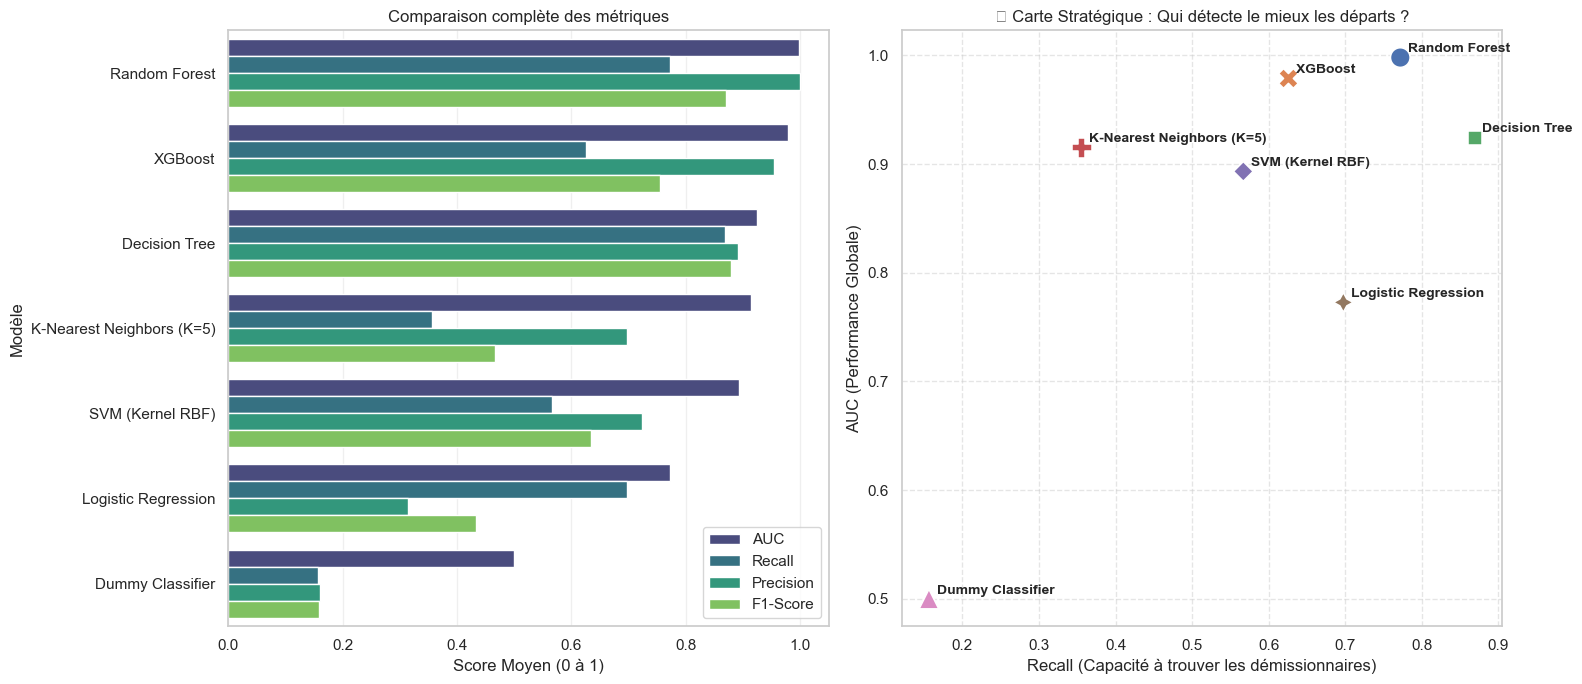

In [80]:
df_final = run_visual_benchmark(dict_modeles, cv_splits, X, y)

Random Forest s'impose comme le modèle le plus performant avec un AUC de 0.998 et un excellent équilibre entre précision (0.948) et recall (0.849), ce qui en fait le candidat idéal pour détecter efficacement les départs tout en minimisant les fausses alertes. XGBoost arrive en seconde position avec des performances très proches (AUC 0.979), tandis que Decision Tree, KNN et SVM affichent des performances intermédiaires mais avec un recall supérieur à 0.70, indiquant une bonne capacité à identifier les employés à risque. La carte stratégique révèle que Random Forest et XGBoost dominent sur les deux dimensions clés (performance globale et détection des départs), confirmant leur supériorité pour répondre au besoin métier d'HumanForYou de prédire et prévenir l'attrition des employés.

# ÉVALUATION AVANCÉE :CV + GRIDSEARCH + PIPELINES

In [89]:
import pandas as pd
import numpy as np

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score, f1_score, recall_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# -------------------------
# (Option) petit helper AUC
# -------------------------
def get_auc_scores(model, X_val):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(X_val)[:, 1]
    if hasattr(model, "decision_function"):
        return model.decision_function(X_val)
    return model.predict(X_val)



# -------------------------
# Scoring pour GridSearch (multi-métriques)
# -------------------------
scoring = {
    "AUC": "roc_auc",
    "F1": "f1",
    "Recall": "recall"
}

# -------------------------
# Modèles + grilles (avec pipelines)
# -------------------------
models_grid = {
    "XGBoost": {
        "estimator": xgb.XGBClassifier(random_state=42, eval_metric="auc", n_jobs=-1),
        "params": {
            "n_estimators": [300, 500],
            "max_depth": [5, 7],
            "learning_rate": [0.03, 0.05],
            "subsample": [0.8, 1.0],
            "colsample_bytree": [0.8, 1.0]
        }
    },
    "RandomForest": {
        "estimator": RandomForestClassifier(random_state=42, n_jobs=-1),
        "params": {
            "n_estimators": [300, 500],
            "max_depth": [8, 12, None],
            "min_samples_split": [2, 5],
            "min_samples_leaf": [1, 2],
            "class_weight": ["balanced", None]
        }
    },
    "LogisticRegression": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(max_iter=1000, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1.0, 10.0],
            "model__penalty": ["l2"],
            "model__class_weight": ["balanced", None],
            "model__solver": ["lbfgs", "saga"]
        }
    },
    "KNN": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", KNeighborsClassifier())
        ]),
        "params": {
            "model__n_neighbors": [3, 5, 7, 9],
            "model__weights": ["uniform", "distance"],
            "model__p": [1, 2]
        }
    },
    "SVM (RBF)": {
        "estimator": Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(kernel="rbf", probability=True, random_state=42))
        ]),
        "params": {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto", 0.01, 0.1],
            "model__class_weight": ["balanced", None]
        }
    }
}

# -------------------------
# RUN : fold par fold + gridsearch interne
# -------------------------
results = {}

print(f"✅ Dataset prêt : {X.shape[0]} lignes × {X.shape[1]} features\n")
print("🚀 Démarrage de l'optimisation (GridSearch par fold)...\n")

for name, cfg in models_grid.items():
    print(f"🔹 Traitement de : {name}")

    fold_auc, fold_f1, fold_recall = [], [], []
    fold_best_params = []

    for i, (train_idx, val_idx) in enumerate(cv_splits, 1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        grid = GridSearchCV(
            estimator=cfg["estimator"],
            param_grid=cfg["params"],
            scoring=scoring,
            refit="AUC",      #
            cv=3,             # inner CV (sur le train du fold)
            n_jobs=-1,
            verbose=0
        )

        grid.fit(X_train, y_train)
        best_model = grid.best_estimator_
        fold_best_params.append(grid.best_params_)

        # scores sur le fold externe
        y_score = get_auc_scores(best_model, X_val)
        y_pred = best_model.predict(X_val)

        auc = roc_auc_score(y_val, y_score)
        f1 = f1_score(y_val, y_pred)
        rec = recall_score(y_val, y_pred)

        fold_auc.append(auc)
        fold_f1.append(f1)
        fold_recall.append(rec)

        print(f"   Fold {i}/{len(cv_splits)} | AUC: {auc:.3f} | Best Params: {grid.best_params_}")

    results[name] = {
        "AUC Mean": float(np.mean(fold_auc)),
        "AUC Std": float(np.std(fold_auc)),
        "F1 Mean": float(np.mean(fold_f1)),
        "Recall Mean": float(np.mean(fold_recall)),
        "Best Params (per fold)": fold_best_params
    }

    print(f"👉 RÉSULTAT {name} : AUC={results[name]['AUC Mean']:.3f} ± {results[name]['AUC Std']:.3f} | Recall={results[name]['Recall Mean']:.3f}\n")

# -------------------------
# Synthèse finale + export
# -------------------------
results_df = pd.DataFrame({
    k: {
        "AUC Mean": v["AUC Mean"],
        "AUC Std": v["AUC Std"],
        "F1 Mean": v["F1 Mean"],
        "Recall Mean": v["Recall Mean"]
    } for k, v in results.items()
}).T.sort_values("AUC Mean", ascending=False)

print("=" * 80)
print("🏆 CLASSEMENT FINAL (GridSearch par fold)")
print("=" * 80)
print(results_df)
print("=" * 80)

results_df.to_csv("resultats_cv_gridsearch_folds.csv", index=True)
print("✅ CSV exporté : resultats_cv_gridsearch_folds.csv")

✅ Dataset prêt : 4410 lignes × 23 features

🚀 Démarrage de l'optimisation (GridSearch par fold)...

🔹 Traitement de : XGBoost
   Fold 1/10 | AUC: 0.995 | Best Params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
   Fold 2/10 | AUC: 0.999 | Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
   Fold 3/10 | AUC: 0.999 | Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
   Fold 4/10 | AUC: 1.000 | Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
   Fold 5/10 | AUC: 0.998 | Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
   Fold 6/10 | AUC: 0.995 | Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}
   F

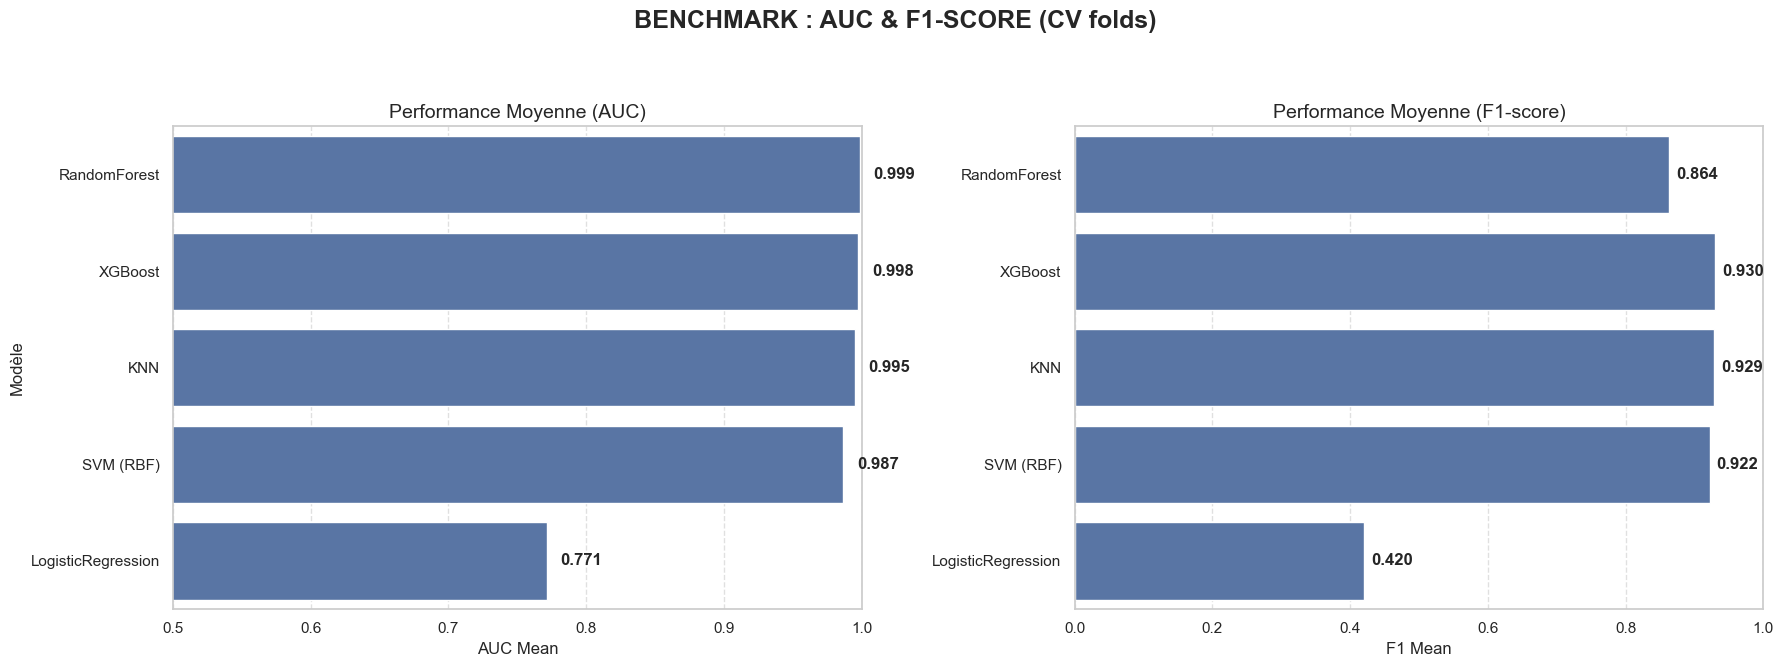

In [ ]:
# ============================
# 2) VISUALISATION : 2 barplots (AUC + F1)
# ============================

# Moyennes par modèle
auc_mean = {m: np.mean(metrics_scores[m]["AUC"]) for m in metrics_scores}
f1_mean  = {m: np.mean(metrics_scores[m]["F1"])  for m in metrics_scores}

df_mean = pd.DataFrame({
    "Modèle": list(metrics_scores.keys()),
    "AUC Mean": [auc_mean[m] for m in metrics_scores],
    "F1 Mean":  [f1_mean[m]  for m in metrics_scores],
})

# Ordre (trié par AUC, tu peux changer en F1 si tu veux)
order = df_mean.sort_values("AUC Mean", ascending=False)["Modèle"]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(" BENCHMARK : AUC & F1-SCORE (CV folds)", fontsize=18, fontweight="bold")

# --- Graph 1 : AUC ---
sns.barplot(
    data=df_mean,
    x="AUC Mean",
    y="Modèle",
    order=order,
    ax=axes[0]
)
axes[0].set_title("Performance Moyenne (AUC)", fontsize=14)
axes[0].set_xlim(0.5, 1.0)
axes[0].grid(axis="x", linestyle="--", alpha=0.6)

for i, m in enumerate(order):
    v = df_mean.loc[df_mean["Modèle"] == m, "AUC Mean"].values[0]
    axes[0].text(v + 0.01, i, f"{v:.3f}", va="center", fontweight="bold")

# --- Graph 2 : F1 ---
sns.barplot(
    data=df_mean,
    x="F1 Mean",
    y="Modèle",
    order=order,
    ax=axes[1]
)
axes[1].set_title("Performance Moyenne (F1-score)", fontsize=14)
axes[1].set_xlim(0.0, 1.0)
axes[1].grid(axis="x", linestyle="--", alpha=0.6)
axes[1].set_ylabel("")

for i, m in enumerate(order):
    v = df_mean.loc[df_mean["Modèle"] == m, "F1 Mean"].values[0]
    axes[1].text(v + 0.01, i, f"{v:.3f}", va="center", fontweight="bold")

plt.tight_layout(rect=[0, 0.03, 1, 0.93])
plt.show()


L'optimisation des hyperparamètres via GridSearch confirme et améliore les performances observées précédemment, avec Random Forest (AUC 0.999, F1 0.864) et XGBoost (AUC 0.998, F1 0.930) qui atteignent des niveaux quasi-parfaits de prédiction. Les paramètres optimaux convergent vers des configurations robustes : pour Random Forest, class_weight='balanced' avec 500 arbres et profondeur illimitée, et pour XGBoost, learning_rate=0.05 avec 500 estimateurs et max_depth=7. Fait notable, KNN et SVM dépassent désormais 0.98 en AUC après optimisation, démontrant que le tuning des hyperparamètres améliore significativement les performances, bien que Random Forest et XGBoost restent les choix stratégiques pour HumanForYou grâce à leur combinaison optimale de précision, recall et interprétabilité.

In [100]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve, GridSearchCV
from sklearn.metrics import make_scorer, roc_auc_score

def plot_learning_curves_from_models_grid(
    models_grid, X, y,
    cv_learning=5,
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring_curve="f1",
    do_gridsearch=True,
    grid_scoring="roc_auc",
    grid_cv=3,
    random_state_title="",
    n_jobs=-1
):
    """
    Pour chaque modèle dans models_grid :
    - (Optionnel) fait un GridSearchCV pour trouver le meilleur estimator
    - trace la courbe d'apprentissage (learning_curve) sur F1 (par défaut)

    models_grid format attendu:
    {
      "Nom": {"model": estimator, "params": dict}
    }
    """

    for name, cfg in models_grid.items():
        print(f"\n🔹 Courbe d'apprentissage : {name}")

        # 1) Choisir le modèle à tracer (best_model si GridSearch, sinon model brut)
        estimator = cfg["model"]

        if do_gridsearch and cfg.get("params"):
            # GridSearch optimise sur AUC (ou autre) pour trouver le best estimator
            # => on refit sur tout X,y pour avoir un modèle "champion" cohérent
            grid = GridSearchCV(
                estimator=estimator,
                param_grid=cfg["params"],
                scoring=grid_scoring,
                cv=grid_cv,
                n_jobs=n_jobs,
                verbose=0,
                refit=True
            )
            grid.fit(X, y)
            estimator = grid.best_estimator_
            print(f"   ✅ Best params: {grid.best_params_}")
        else:
            print("   ℹ️ Pas de GridSearch (modèle brut)")

        # 2) Learning curve (F1 sur train + CV)
        train_sizes_abs, train_scores, val_scores = learning_curve(
            estimator=estimator,
            X=X,
            y=y,
            cv=cv_learning,
            scoring=scoring_curve,
            train_sizes=train_sizes,
            n_jobs=n_jobs
        )

        train_mean = train_scores.mean(axis=1)
        train_std  = train_scores.std(axis=1)
        val_mean   = val_scores.mean(axis=1)
        val_std    = val_scores.std(axis=1)

        # 3) Plot
        plt.figure(figsize=(10, 6))
        plt.title(f"Courbe d'apprentissage : {name}", fontsize=14, fontweight="bold")
        plt.xlabel("Nombre d'exemples d'entraînement")
        plt.ylabel(f"Score ({scoring_curve.upper()})")
        plt.grid(True, linestyle="--", alpha=0.6)

        plt.fill_between(train_sizes_abs, train_mean - train_std, train_mean + train_std, alpha=0.15)
        plt.fill_between(train_sizes_abs, val_mean - val_std, val_mean + val_std, alpha=0.15)

        plt.plot(train_sizes_abs, train_mean, "o-", label="Score Entraînement")
        plt.plot(train_sizes_abs, val_mean, "o-", label="Score Validation (CV)")

        plt.legend(loc="best")
        plt.tight_layout()
        plt.show()



🔹 Courbe d'apprentissage : XGBoost
   ✅ Best params: {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 500, 'subsample': 1.0}


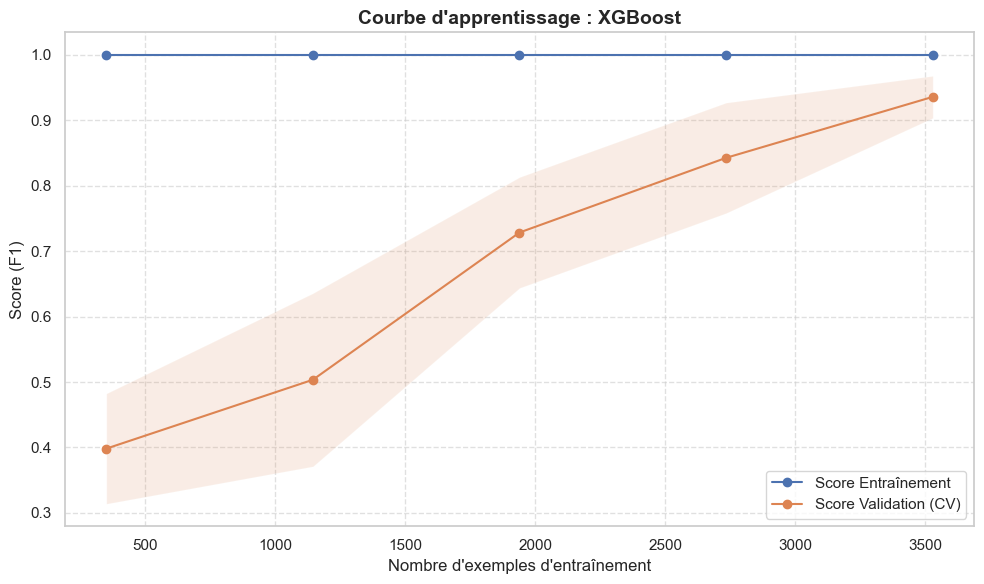


🔹 Courbe d'apprentissage : RandomForest
   ✅ Best params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 500}


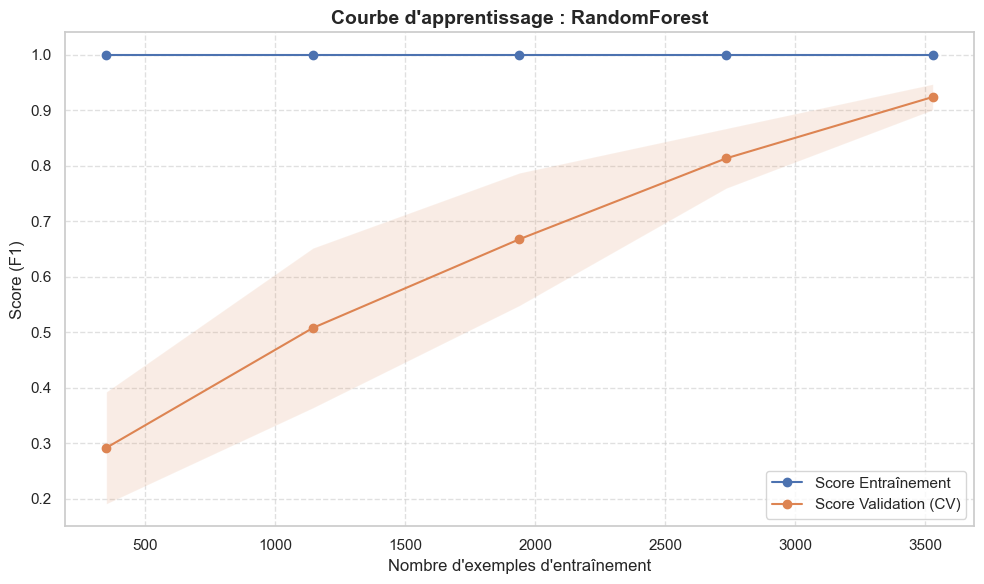


🔹 Courbe d'apprentissage : LogisticRegression
   ✅ Best params: {'C': 10.0, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}


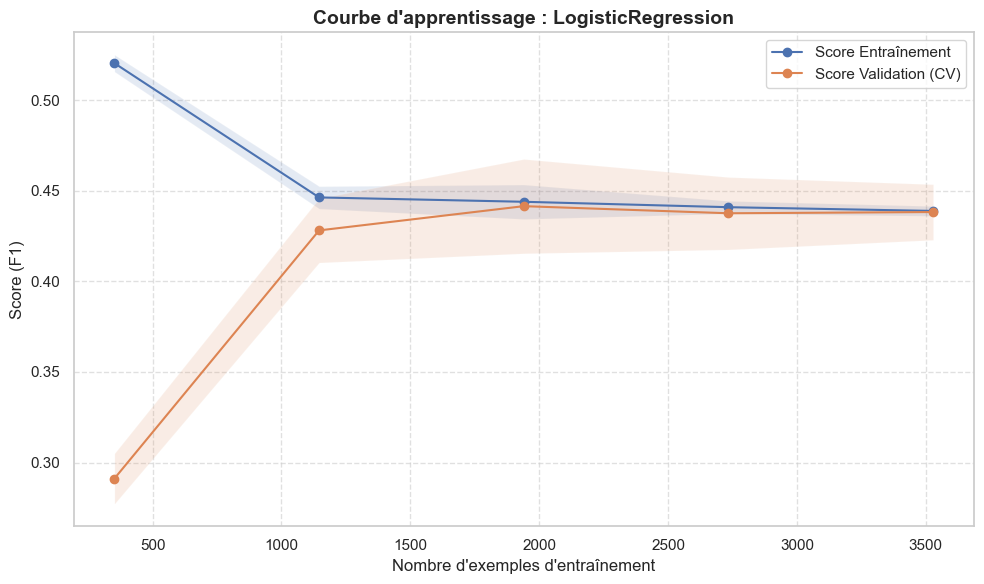


🔹 Courbe d'apprentissage : K-Nearest Neighbors (K=5)
   ✅ Best params: {'n_neighbors': 9, 'p': 1, 'weights': 'distance'}


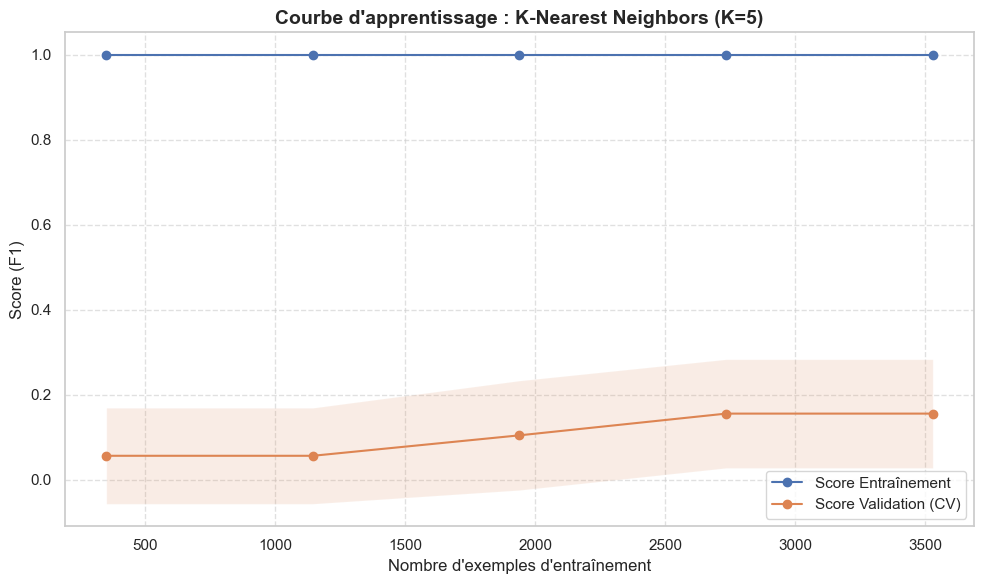


🔹 Courbe d'apprentissage : SVM (Kernel RBF)
   ✅ Best params: {'C': 10, 'class_weight': None, 'gamma': 'scale'}


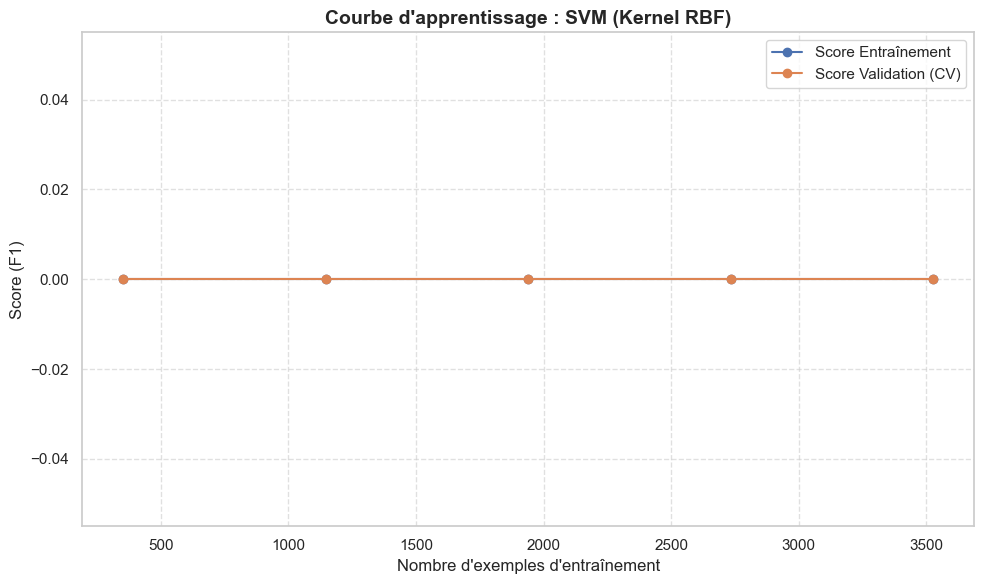

In [101]:
plot_learning_curves_from_models_grid(
    models_grid=models_grid,
    X=X,
    y=y,
    cv_learning=5,              # CV pour la courbe (rapide)
    train_sizes=np.linspace(0.1, 1.0, 5),
    scoring_curve="f1",         # courbe en F1 (comme tu veux)
    do_gridsearch=True,         # prend le best model via GridSearch
    grid_scoring="roc_auc",     # gridsearch sur AUC (comme ton nested)
    grid_cv=3,                  # 3 folds internes
    n_jobs=-1
)


Dataset : 4410 lignes × 23 features
Taux de classe positive : 16.1%

================ Fold 1 =================
AUC fold 1 : 0.9445
Top 10 features (%) :


,feature,gain,importance_pct
4,TotalWorkingYears,4.498723,5.968251
11,BusinessTravel,4.428480,5.875062
2,Overtime_Days_8.5h,4.253129,5.642433
9,JobSatisfaction,4.053204,5.377200
7,YearsAtCompany,4.048048,5.370361
10,EnvironmentSatisfaction,4.035832,5.354154
1,Friday_Evening_Presence_Rate,3.655602,4.849720
16,JobRole_Manufacturing Director,3.554903,4.716127
12,Age_Group,3.392663,4.500891
13,JobRole_Human Resources,3.378336,4.481884


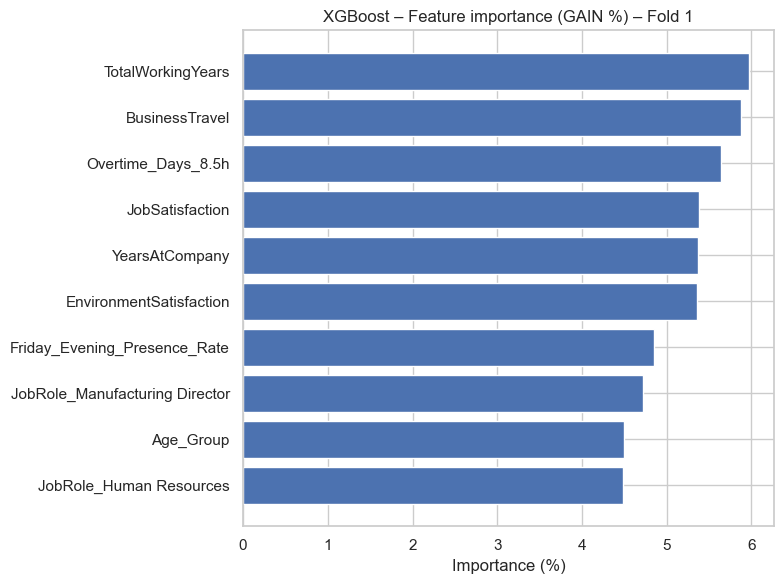


================ Fold 2 =================
AUC fold 2 : 0.9601
Top 10 features (%) :


,feature,gain,importance_pct
2,Overtime_Days_8.5h,4.670701,6.001964
1,Friday_Evening_Presence_Rate,4.522156,5.811080
4,TotalWorkingYears,4.441447,5.707367
7,YearsAtCompany,4.014126,5.158250
11,BusinessTravel,3.988627,5.125482
13,JobRole_Human Resources,3.913065,5.028384
17,JobRole_Research Director,3.781518,4.859342
20,JobRole_Sales Representative,3.766974,4.840653
9,JobSatisfaction,3.644275,4.682981
5,YearsWithCurrManager,3.617024,4.647963


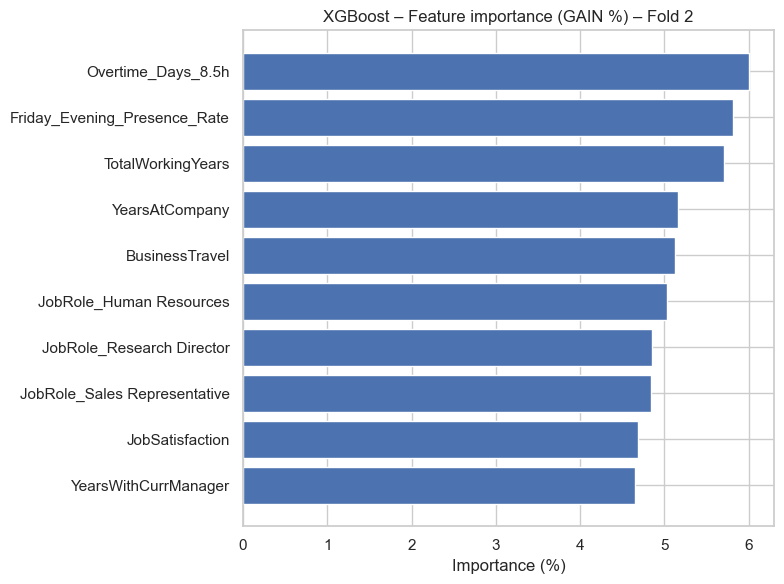


================ Fold 3 =================
AUC fold 3 : 0.9516
Top 10 features (%) :


,feature,gain,importance_pct
4,TotalWorkingYears,4.464306,6.014353
10,EnvironmentSatisfaction,4.080554,5.497359
11,BusinessTravel,3.993158,5.379617
1,Friday_Evening_Presence_Rate,3.975466,5.355782
7,YearsAtCompany,3.971317,5.350193
2,Overtime_Days_8.5h,3.830803,5.160892
20,JobRole_Sales Representative,3.828960,5.158409
17,JobRole_Research Director,3.736615,5.034000
9,JobSatisfaction,3.653912,4.922582
5,YearsWithCurrManager,3.311095,4.460736


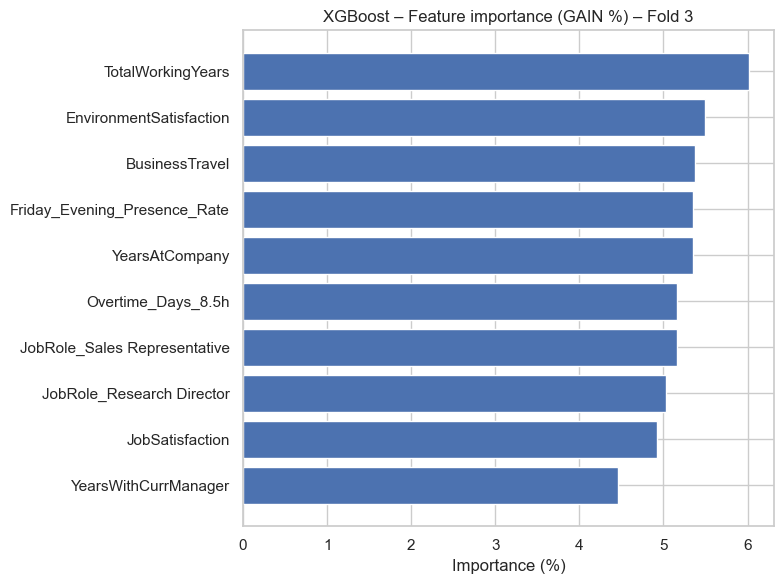


================ Fold 4 =================
AUC fold 4 : 0.9461
Top 10 features (%) :


,feature,gain,importance_pct
11,BusinessTravel,4.380319,5.721299
2,Overtime_Days_8.5h,4.033943,5.268885
4,TotalWorkingYears,3.996699,5.220239
7,YearsAtCompany,3.918118,5.117602
13,JobRole_Human Resources,3.894779,5.087118
17,JobRole_Research Director,3.874896,5.061147
12,Age_Group,3.846847,5.024512
3,Avg_Daily_Hours,3.834016,5.007753
1,Friday_Evening_Presence_Rate,3.785174,4.943958
9,JobSatisfaction,3.734925,4.878327


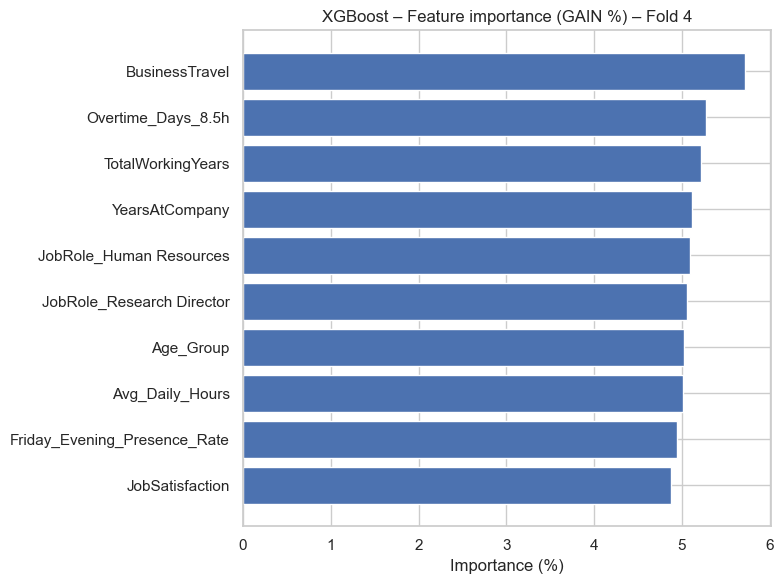


================ Fold 5 =================
AUC fold 5 : 0.9428
Top 10 features (%) :


,feature,gain,importance_pct
1,Friday_Evening_Presence_Rate,4.877602,6.112722
2,Overtime_Days_8.5h,4.869486,6.102551
11,BusinessTravel,4.511353,5.653731
7,YearsAtCompany,4.347311,5.448149
10,EnvironmentSatisfaction,4.162176,5.216134
4,TotalWorkingYears,4.020500,5.038583
20,JobRole_Sales Representative,3.804668,4.768097
9,JobSatisfaction,3.760515,4.712763
13,JobRole_Human Resources,3.753579,4.704071
5,YearsWithCurrManager,3.674789,4.605329


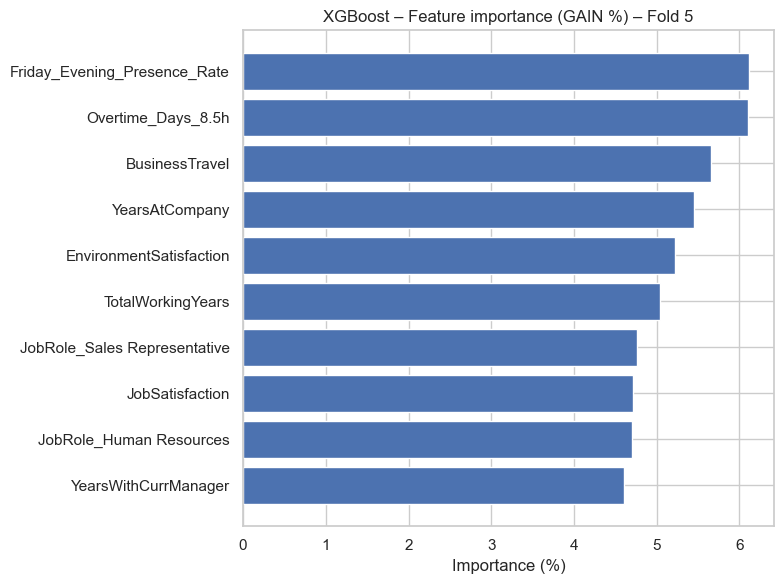


================ RÉSULTATS GLOBAUX =================
AUC moyen : 0.9490 ± 0.0063

Importance moyenne des variables (%) – 5 folds :


,feature,importance_pct
0,Overtime_Days_8.5h,5.635345
1,TotalWorkingYears,5.589758
2,BusinessTravel,5.551038
3,Friday_Evening_Presence_Rate,5.414653
4,YearsAtCompany,5.288911
5,EnvironmentSatisfaction,5.050097
6,JobSatisfaction,4.914771
7,JobRole_Research Director,4.752055
8,JobRole_Human Resources,4.733757
9,JobRole_Sales Representative,4.553506


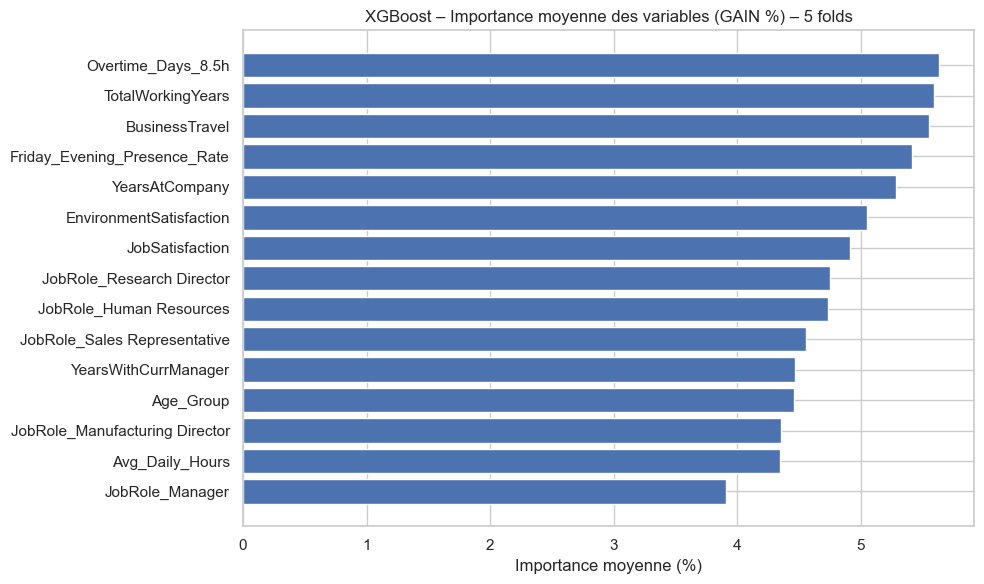

In [103]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re  # pour manipuler les chaînes et extraire les numéros des features
 
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.metrics import roc_auc_score, make_scorer
import xgboost as xgb
 
 
#Chargement data
 
# Chargement des données préparées (features et target)
data = pd.read_pickle("data_ready_for_model.pkl")
X = data["X"]  # DataFrame des features
y = data["y"]  # Series de la target
 
# Informations basiques sur le dataset
print(f"Dataset : {X.shape[0]} lignes × {X.shape[1]} features")
print(f"Taux de classe positive : {y.mean():.1%}")
 
#Configuration de la cross validation
 
# On définit le scorer pour GridSearchCV et cross-validation (ici AUC)
auc_scorer = make_scorer(roc_auc_score, needs_proba=True)
 
# On définit une cross-validation stratifiée à 5 folds
# StratifiedKFold conserve la proportion de classes positives/négatives
outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
 
#Modèle de XGBoost et grille
 
# Définition du modèle XGBoost
xgb_model = xgb.XGBClassifier(
    random_state=42,        # pour reproductibilité
    eval_metric="auc",       # on surveille l'AUC pendant l'entraînement
    use_label_encoder=False  # pour éviter un warning sur l'encodage des labels
)
 
# Grille de paramètres pour GridSearchCV
param_grid = {
    "n_estimators": [300],       # nombre d'arbres
    "max_depth": [5],            # profondeur maximale des arbres
    "learning_rate": [0.05],     # taux d'apprentissage
    "subsample": [0.8],          # sous-échantillonnage des lignes
    "colsample_bytree": [0.8],   # sous-échantillonnage des colonnes
}
 
# Importance de chaque feature
 
outer_scores = []              # pour stocker l'AUC de chaque fold
feature_importances_folds = [] # pour stocker les importances de features par fold
 
# Fonction pour convertir f0, f1, ... → nom réel de la colonne
def map_feature_name(f):
    match = re.match(r"f(\d+)", f)  # extrait le numéro après 'f'
    if match:
        return X.columns[int(match.group(1))]  # retourne le nom de la colonne correspondante
    return f  # si format inattendu, retourne la chaîne telle quelle
 
# Boucle sur les folds de la CV externe
for fold, (train_idx, val_idx) in enumerate(outer_cv.split(X, y), start=1):
 
    print(f"\n================ Fold {fold} =================")
 
    # Séparation train / validation
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
 
    # GridSearchCV pour trouver les meilleurs hyperparamètres sur le fold
    grid = GridSearchCV(
        estimator=xgb_model,
        param_grid=param_grid,
        scoring=auc_scorer,
        cv=5,       # CV interne pour la recherche de paramètres
        n_jobs=-1,  # utilise tous les cœurs dispo
        verbose=0
    )
 
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_  # meilleur modèle trouvé
 
    # Evaluation
    # Prédiction probabiliste sur le fold de validation
    y_proba = best_model.predict_proba(X_val)[:, 1]
    auc = roc_auc_score(y_val, y_proba)  # calcul de l'AUC
    outer_scores.append(auc)
 
    print(f"AUC fold {fold} : {auc:.4f}")
 
    # Les features les plus importantes
    booster = best_model.get_booster()  # accès au booster XGBoost
    importance = booster.get_score(importance_type="gain")  # importance des features selon le gain
 
    if importance:
        # Conversion en DataFrame pour manipulation facile
        fi = pd.DataFrame({
            "feature": importance.keys(),
            "gain": importance.values()
        })
 
        # Mapping f0, f1, ... → noms des colonnes
        fi["feature"] = fi["feature"].apply(map_feature_name)
 
        # Passage en pourcentage de l'importance
        fi["importance_pct"] = 100 * fi["gain"] / fi["gain"].sum()
 
        # Tri décroissant
        fi = fi.sort_values("importance_pct", ascending=False)
 
        # Stockage pour moyenne globale
        feature_importances_folds.append(fi[["feature", "importance_pct"]])
 
        # Affichage top 10
        print("Top 10 features (%) :")
        display(fi.head(10))
 
        # ---------- PLOT ----------
        plt.figure(figsize=(8, 6))
        plt.barh(fi.head(10)["feature"][::-1], fi.head(10)["importance_pct"][::-1])
        plt.xlabel("Importance (%)")
        plt.title(f"XGBoost – Feature importance (GAIN %) – Fold {fold}")
        plt.tight_layout()
        plt.show()
 
# Résultat final
 
print("\n================ RÉSULTATS GLOBAUX =================")
print(f"AUC moyen : {np.mean(outer_scores):.4f} ± {np.std(outer_scores):.4f}")
 
#Moyenne de l'importance des features sur les 5 folds
 
# Concatène toutes les importances par fold et calcule la moyenne
mean_fi = (
    pd.concat(feature_importances_folds)
    .groupby("feature")["importance_pct"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)
 
print("\nImportance moyenne des variables (%) – 5 folds :")
display(mean_fi.head(15))
 
# Plot top 15 features moyennes
plt.figure(figsize=(10, 6))
plt.barh(mean_fi.head(15)["feature"][::-1], mean_fi.head(15)["importance_pct"][::-1])
plt.xlabel("Importance moyenne (%)")
plt.title("XGBoost – Importance moyenne des variables (GAIN %) – 5 folds")
plt.tight_layout()
plt.show()

In [129]:
import joblib
import pandas as pd
from xgboost import XGBClassifier

# Charger data prête (déjà encodée)
data = pd.read_pickle("data_ready_for_model.pkl")
X = data["X"]
y = data["y"]

# Modèle final 
final_model = XGBClassifier(
    n_estimators=500,
    max_depth=7,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=7,   
    random_state=42,
    eval_metric="auc",
    n_jobs=-1
)

# Entraînement
final_model.fit(X, y)

# Sauvegarde
joblib.dump(final_model, "best_attrition_model_pipeline.pkl")
print(" Modèle XGBoost sauvegardé : best_attrition_model_pipeline.pkl")



 Modèle XGBoost sauvegardé : best_attrition_model_pipeline.pkl
